In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

(Epoch 1) Training: Loss - 635.2739 mAP - 0.0000 | Validation: Loss - 337.3474578857422 mAP - 0.0
(Epoch 2) Training: Loss - 48.9296 mAP - 0.0000 | Validation: Loss - 8.617079257965088 mAP - 0.0
(Epoch 3) Training: Loss - 11.3297 mAP - 0.0000 | Validation: Loss - 6.8594290018081665 mAP - 0.0


NameError: name 'math' is not defined

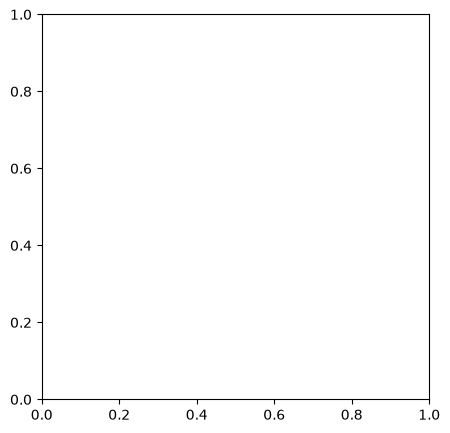

In [2]:
from src.transforms import trainval_transforms, test_transforms
from src.inference_functions import compute_eval_stats
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import random_split, DataLoader
from src.visualization import plot_history
from src.configs import SEED, BATCH_SIZE
from src.train_functions import train
from src.dataset import ImageDataset
from src.loss_function import Loss
from src.model import Model
from pathlib import Path
import torch

annot_file_trainval = Path("../data/preprocessed/trainval/annotations.csv")
img_dir_trainval = Path("../data/preprocessed/trainval/Images")

# 1. Datasets and DataLoaders
trainval_dataset = ImageDataset(annot_file_trainval, img_dir_trainval,
                                transform=trainval_transforms)

generator_ = torch.Generator().manual_seed(SEED)
_, train_dataset, val_dataset = random_split(trainval_dataset, [0.9, 0.08, 0.02]
                                          ,generator=generator_)

train_dl = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# 2. Instantiate model, loss function, device, optimizer, and scheduler
device = "cuda" if torch.cuda.is_available() else "cpu"
num_epochs = 3

model = Model().to(device)
loss_fn = Loss().to(device)

optimizer = torch.optim.SGD(model.parameters(), 1e-2, 0.9, weight_decay=0.0005)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-4)

# 3. Training loop
checkpoint_dir = Path("../outputs/checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

train_loss_history, val_loss_history = [], []
train_mAP_history, val_mAP_history = [], []

for epoch in range(num_epochs):
    # a. Train Model
    train_loss = train(model, loss_fn, optimizer, train_dl, device)
    scheduler.step()

    # b. Evaluate Model Performance on Training Dataset
    train_mAP = compute_eval_stats(model, train_dl, device)
    train_loss_history.append(train_loss)
    train_mAP_history.append(train_mAP)

    # c. Evaluate Model Performance on Validation Dataset
    val_mAP, val_loss = compute_eval_stats(model, val_dl, device, loss_fn)
    val_loss_history.append(val_loss)
    val_mAP_history.append(val_mAP)

    # d. Save Checkpoints
    checkpoint = {
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, checkpoint_dir / f"checkpoint_epoch_{epoch+1}.pth")

    # e. Display Statistics
    print(f"(Epoch {epoch+1}) Training: Loss - {train_loss:.4f} mAP - "
          f"{train_mAP:.4f} | Validation: Loss - {val_loss} mAP - {val_mAP}")

# 4. Plot and save all the history lists
epoch_list = list(range(1, num_epochs+1))

plot_history(epoch_list, train_loss_history, "training_loss")
plot_history(epoch_list, val_loss_history, "val_loss")
plot_history(epoch_list, train_mAP_history, "training_mAP")
plot_history(epoch_list, val_mAP_history, "val_mAP")

In [3]:
for epoch in range(5):
    # a. Train Model
    train_loss = train(model, loss_fn, optimizer, train_dl, device)
    scheduler.step()

    # b. Evaluate Model Performance on Training Dataset
    train_mAP = compute_eval_stats(model, train_dl, device)
    train_loss_history.append(train_loss)
    train_mAP_history.append(train_mAP)

    # c. Evaluate Model Performance on Validation Dataset
    val_mAP, val_loss = compute_eval_stats(model, val_dl, device, loss_fn)
    val_loss_history.append(val_loss)
    val_mAP_history.append(val_mAP)

    # d. Save Checkpoints
    checkpoint = {
        "epoch": epoch+1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, checkpoint_dir / f"checkpoint_epoch_{epoch+1}.pth")

    # e. Display Statistics
    print(f"(Epoch {epoch+1}) Training: Loss - {train_loss:.4f} mAP - "
          f"{train_mAP:.4f} | Validation: Loss - {val_loss} mAP - {val_mAP}")

(Epoch 1) Training: Loss - 9.8454 mAP - 0.0000 | Validation: Loss - 6.798567056655884 mAP - 0.0
(Epoch 2) Training: Loss - 9.3429 mAP - 0.0000 | Validation: Loss - 6.869861721992493 mAP - 0.0
(Epoch 3) Training: Loss - 8.8574 mAP - 0.0000 | Validation: Loss - 6.409722924232483 mAP - 0.0
(Epoch 4) Training: Loss - 8.2897 mAP - 0.0000 | Validation: Loss - 6.3864123821258545 mAP - 0.0
(Epoch 5) Training: Loss - 7.9467 mAP - 0.0000 | Validation: Loss - 6.316068470478058 mAP - 0.0
